# Lab Instructions

You have been hired by James Cameron to create profiles of two characters for a reboot of the Titanic Movie: one that is most likely to survive the sinking and one that is least likely to survive.  Mr. Cameron wants this reboot to be as historically accurate as possible, so your profile of each character should be backed up with data and visualizations.

Each character profile should include information on their:
* Age, fare
* Sex
* Passenger class
* Travel companions (including both parents/children and siblings/spouse)
* Port of departure (indicated by the Embarked feature in the dataset)

For quantitative features like `Age` and `Fare`, you will need to use the `.loc` method we learned in class (or something similar) to place individuals in categories.  How you choose to do this is up to you, but make sure you explain your reasoning.

You should include at least one visualization for each element of the character profile (age, sex, passenger class, etc.) as evidence.

After you have developed your two character profiles, use your Pandas data wrangling skills to identify at least one real passenger in the dataset that fits each profile.  Print out the names of these individuals.  Look them up in [Encyclopeida Titanica](https://www.encyclopedia-titanica.org/) (or a similar resource).  

Tell Mr. Cameron at least one thing about the real passengers who fit your two character profiles that you learned from an external resource.  You need one interesting fact about a person who fits the profile of "most likely to survive" and one interesting fact about a person who fits the profile of "least likely to surivive".  



In [1]:
import pandas as pd

df = pd.read_csv('titanic_passengers.csv')

df.head(25)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [2]:
df['Fare'].describe()

count    891.000000
mean      32.204208
std       49.693429
min        0.000000
25%        7.910400
50%       14.454200
75%       31.000000
max      512.329200
Name: Fare, dtype: float64


## Quantitative Features

The quantitative features used in this lab are:

- **Age**
- **Fare**
- **SibSp** (siblings/spouses aboard)
- **Parch** (parents/children aboard)

To make the character profiles easier to interpret, I grouped these into broader categories. I used age groups and fare ranges so the results would be more meaningful than looking at every exact number one by one. I also combined `SibSp` and `Parch` into one total-companions feature because both describe who a passenger was traveling with.


In [3]:

import numpy as np
import matplotlib.pyplot as plt

# Total travel companions
df['Companions'] = df['SibSp'] + df['Parch']

# Categories for quantitative features
df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=[0, 12, 18, 35, 60, 100],
    labels=['Child (0-12)', 'Teen (13-18)', 'Young Adult (19-35)', 'Adult (36-60)', 'Senior (61+)'],
    include_lowest=True
)

df['FareGroup'] = pd.cut(
    df['Fare'],
    bins=[-0.01, 10, 25, 50, 100, 600],
    labels=['Very Low (0-10)', 'Low (10-25)', 'Medium (25-50)', 'High (50-100)', 'Very High (100+)']
)

df['CompanionGroup'] = pd.cut(
    df['Companions'],
    bins=[-1, 0, 2, 20],
    labels=['Alone (0)', 'Small Group (1-2)', 'Large Group (3+)']
)

df[['Age', 'AgeGroup', 'Fare', 'FareGroup', 'Companions', 'CompanionGroup']].head(10)


,Age,AgeGroup,Fare,FareGroup,Companions,CompanionGroup
0,22.0,Young Adult (19-35),7.2500,Very Low (0-10),1,Small Group (1-2)
1,38.0,Adult (36-60),71.2833,High (50-100),1,Small Group (1-2)
2,26.0,Young Adult (19-35),7.9250,Very Low (0-10),0,Alone (0)
3,35.0,Young Adult (19-35),53.1000,High (50-100),1,Small Group (1-2)
4,35.0,Young Adult (19-35),8.0500,Very Low (0-10),0,Alone (0)
5,NaN,NaN,8.4583,Very Low (0-10),0,Alone (0)
6,54.0,Adult (36-60),51.8625,High (50-100),0,Alone (0)
7,2.0,Child (0-12),21.0750,Low (10-25),4,Large Group (3+)
8,27.0,Young Adult (19-35),11.1333,Low (10-25),2,Small Group (1-2)
9,14.0,Teen (13-18),30.0708,Medium (25-50),1,Small Group (1-2)



## Why I chose these categories

I used these groupings because they make the patterns easier to compare.

- **Age groups:** children, teens, young adults, adults, and seniors
- **Fare groups:** very low, low, medium, high, and very high
- **Companions:** alone, small group, or large group

These categories help show which types of passengers were more likely to survive without relying on exact ages or fares for every single person.


## 1. Sex

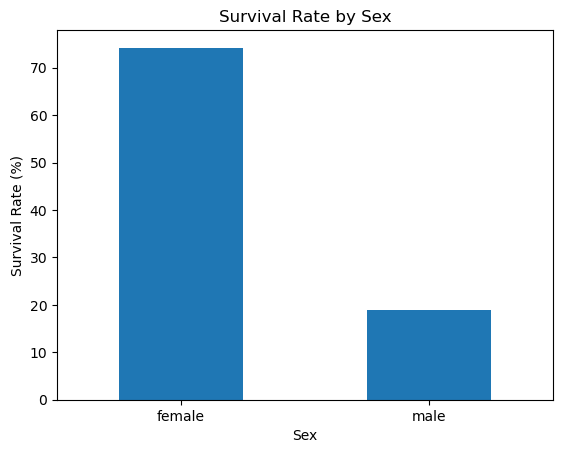

Sex
female    74.20
male      18.89
Name: Survived, dtype: float64

In [4]:

sex_survival = df.groupby('Sex')['Survived'].mean().sort_values(ascending=False) * 100
sex_survival.plot(kind='bar')
plt.title('Survival Rate by Sex')
plt.xlabel('Sex')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.show()

sex_survival.round(2)



**Description:** Female passengers had a much higher survival rate than male passengers. This makes sex one of the strongest predictors of survival in the dataset. A passenger most likely to survive would be female, while a passenger least likely to survive would be male.


## 2. Passenger Class

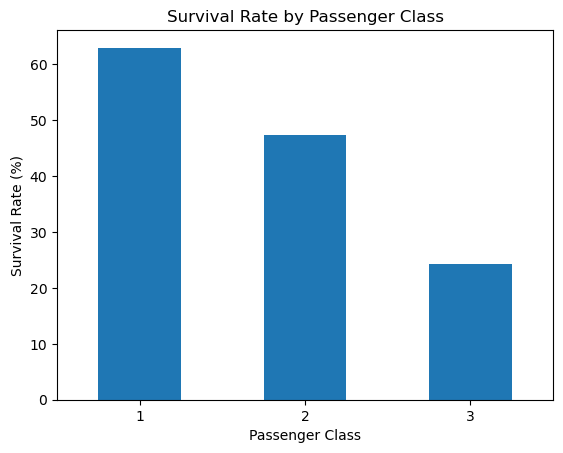

Pclass
1    62.96
2    47.28
3    24.24
Name: Survived, dtype: float64

In [5]:

class_survival = df.groupby('Pclass')['Survived'].mean().sort_values(ascending=False) * 100
class_survival.plot(kind='bar')
plt.title('Survival Rate by Passenger Class')
plt.xlabel('Passenger Class')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.show()

class_survival.round(2)



**Description:** First-class passengers had the highest survival rate, second-class passengers were in the middle, and third-class passengers had the lowest survival rate. Because of that, the most likely survivor profile should be a first-class passenger, while the least likely survivor profile should be a third-class passenger.


## 3. Port of Departure

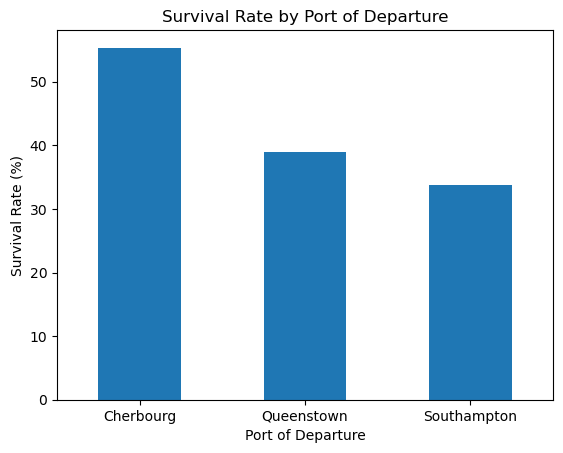

Embarked
Cherbourg      55.36
Queenstown     38.96
Southampton    33.70
Name: Survived, dtype: float64

In [6]:

embarked_survival = df.groupby('Embarked')['Survived'].mean().sort_values(ascending=False) * 100
embarked_survival.index = embarked_survival.index.map({'C': 'Cherbourg', 'Q': 'Queenstown', 'S': 'Southampton'})
embarked_survival.plot(kind='bar')
plt.title('Survival Rate by Port of Departure')
plt.xlabel('Port of Departure')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.show()

embarked_survival.round(2)



**Description:** Passengers who embarked from **Cherbourg (C)** had the highest survival rate. Passengers from **Southampton (S)** had the lowest overall among the main ports. This suggests the most likely survivor profile would leave from Cherbourg, while the least likely survivor profile would leave from Southampton.


## 4. Age Groups

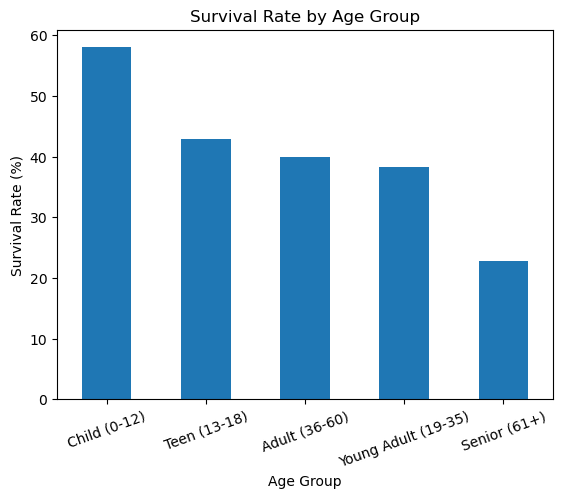

AgeGroup
Child (0-12)           57.97
Teen (13-18)           42.86
Adult (36-60)          40.00
Young Adult (19-35)    38.27
Senior (61+)           22.73
Name: Survived, dtype: float64

In [7]:

age_survival = df.groupby('AgeGroup', observed=False)['Survived'].mean().sort_values(ascending=False) * 100
age_survival.plot(kind='bar')
plt.title('Survival Rate by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=20)
plt.show()

age_survival.round(2)



**Description:** Children had the highest survival rate overall, while seniors had the lowest. Age mattered, but it was not as strong as sex or passenger class. For the most likely survivor profile, I would place the passenger in a younger age group. For the least likely survivor profile, I would place the passenger in an older adult group.


## 5. Fare Groups

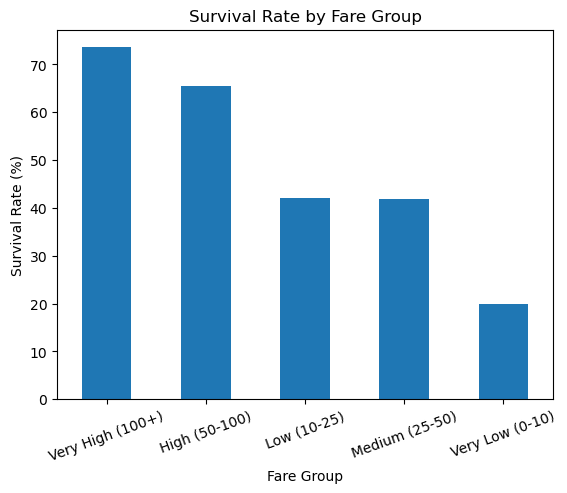

FareGroup
Very High (100+)    73.58
High (50-100)       65.42
Low (10-25)         42.08
Medium (25-50)      41.95
Very Low (0-10)     19.94
Name: Survived, dtype: float64

In [8]:

fare_survival = df.groupby('FareGroup', observed=False)['Survived'].mean().sort_values(ascending=False) * 100
fare_survival.plot(kind='bar')
plt.title('Survival Rate by Fare Group')
plt.xlabel('Fare Group')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=20)
plt.show()

fare_survival.round(2)



**Description:** Survival rate increased as fare increased. Passengers in the **highest fare groups** survived the most often, while passengers in the **very low fare group** survived the least. That means the most likely survivor profile should have a high fare, and the least likely survivor profile should have a very low fare.


## 6. Travel Companions

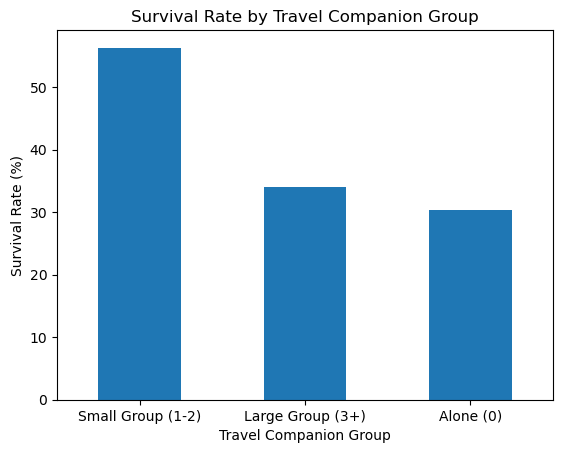

CompanionGroup
Small Group (1-2)    56.27
Large Group (3+)     34.07
Alone (0)            30.35
Name: Survived, dtype: float64

In [9]:

companion_survival = df.groupby('CompanionGroup', observed=False)['Survived'].mean().sort_values(ascending=False) * 100
companion_survival.plot(kind='bar')
plt.title('Survival Rate by Travel Companion Group')
plt.xlabel('Travel Companion Group')
plt.ylabel('Survival Rate (%)')
plt.xticks(rotation=0)
plt.show()

companion_survival.round(2)



**Description:** Passengers traveling in a **small group (1-2 companions)** had the highest survival rate. Passengers traveling alone or in large groups had lower survival rates. Because of that, the most likely survivor profile should travel with a small group, while the least likely survivor profile should be alone or in a large group.



## Summary of the strongest patterns

After comparing the categorical relationships, the strongest survival profile in this dataset is:

- **Female**
- **1st class**
- **Embarked from Cherbourg**
- **Younger passenger**
- **High fare**
- **Traveling with 1-2 companions**

The least likely survival profile is:

- **Male**
- **3rd class**
- **Embarked from Southampton**
- **Older passenger**
- **Very low fare**
- **Traveling alone**



## "Most likely to survive" character profile

The passenger most likely to survive would be a **female first-class passenger** who **embarked from Cherbourg**, paid a **high fare**, belonged to a **younger age group**, and traveled with **1-2 companions**.

This profile matches the general pattern that women and higher-class passengers were given better chances of survival. A high fare also suggests access to first-class accommodations, which were closer to the lifeboats and crew assistance.



## "Least likely to survive" character profile

The passenger least likely to survive would be a **male third-class passenger** who **embarked from Southampton**, paid a **very low fare**, belonged to an **older age group**, and was **traveling alone**.

This profile matches the lowest-survival categories in the data. Third-class male passengers with low fares had the fewest advantages during the evacuation and were the least likely to survive.



## Real passengers who fit the profiles

Below are two real passengers from the dataset who are close matches for the profiles above.


In [10]:

# Example passenger close to the "most likely to survive" profile
most_likely_example = df.loc[df['Name'].str.contains('Astor, Mrs. John Jacob', na=False),
                             ['Name', 'Age', 'Sex', 'Pclass', 'Fare', 'Embarked', 'SibSp', 'Parch', 'Survived']]
most_likely_example


,Name,Age,Sex,Pclass,Fare,Embarked,SibSp,Parch,Survived
700,"Astor, Mrs. John Jacob (Madeleine Talmadge Force)",18.0,female,1,227.525,C,1,0,1



**Most likely survivor example:** **Astor, Mrs. John Jacob (Madeleine Talmage Force)**

- She was a **female first-class passenger**
- She **embarked from Cherbourg**
- She paid a **very high fare**
- She **survived**
- Interesting fact: Madeleine Astor was pregnant during the voyage and survived after boarding Lifeboat 4, while her husband John Jacob Astor IV died in the disaster.


In [11]:

# Example passenger close to the "least likely to survive" profile
least_likely_example = df.loc[df['Name'].str.contains('Allen, Mr. William Henry', na=False),
                              ['Name', 'Age', 'Sex', 'Pclass', 'Fare', 'Embarked', 'SibSp', 'Parch', 'Survived']]
least_likely_example


,Name,Age,Sex,Pclass,Fare,Embarked,SibSp,Parch,Survived
4,"Allen, Mr. William Henry",35.0,male,3,8.05,S,0,0,0



**Least likely survivor example:** **Allen, Mr. William Henry**

- He was a **male third-class passenger**
- He **embarked from Southampton**
- He paid a **very low fare**
- He did **not survive**
- Interesting fact: William Henry Allen was an English tool maker who was traveling to the United States for work when he boarded the Titanic.



## Final conclusion

The Titanic data shows that **sex** and **passenger class** were the strongest factors related to survival. Women, first-class passengers, and passengers who paid higher fares had the best odds. Men, third-class passengers, and passengers who paid very low fares had the worst odds. By grouping the quantitative features into categories, it became easier to build realistic passenger profiles that match the historical patterns in the dataset.
